In [ ]:
%reset -f

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Solar_Energy_Production.csv")
df['date'] = pd.to_datetime(df.date, format="%Y/%m/%d %I:%M:%S %p")
df = df.set_index("date", drop=False)
display(df)

,name,id,address,date,kWh,public_url,installationDate,uid
date,,,,,,,,
2017-09-11 08:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 08:00:00,1.130,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 08:00:00
2017-09-11 09:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 09:00:00,2.340,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 09:00:00
2017-09-11 10:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 10:00:00,3.656,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 10:00:00
2017-09-11 11:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 11:00:00,4.577,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 11:00:00
2017-09-11 12:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 12:00:00,6.506,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 12:00:00
...,...,...,...,...,...,...,...,...
2023-03-12 15:00:00,Bearspaw Water Treatment Plant,577650,11444 Bearspaw Dam RD NW,2023-03-12 15:00:00,201.285,https://monitoringpublic.solaredge.com/solared...,2017/10/31,5776502023-03-12 15:00:00
2023-03-12 16:00:00,Bearspaw Water Treatment Plant,577650,11444 Bearspaw Dam RD NW,2023-03-12 16:00:00,162.582,https://monitoringpublic.solaredge.com/solared...,2017/10/31,5776502023-03-12 16:00:00
2023-03-12 17:00:00,Bearspaw Water Treatment Plant,577650,11444 Bearspaw Dam RD NW,2023-03-12 17:00:00,107.060,https://monitoringpublic.solaredge.com/solared...,2017/10/31,5776502023-03-12 17:00:00


In [ ]:
print(df.address.unique().size)

11


There are 11 distinct sites, identifiable with ID or address

In [ ]:
display(df.date.head(), df.date.tail())

,date
date,
2017-09-11 08:00:00,2017-09-11 08:00:00
2017-09-11 09:00:00,2017-09-11 09:00:00
2017-09-11 10:00:00,2017-09-11 10:00:00
2017-09-11 11:00:00,2017-09-11 11:00:00
2017-09-11 12:00:00,2017-09-11 12:00:00


,date
date,
2023-03-12 15:00:00,2023-03-12 15:00:00
2023-03-12 16:00:00,2023-03-12 16:00:00
2023-03-12 17:00:00,2023-03-12 17:00:00
2023-03-12 18:00:00,2023-03-12 18:00:00
2023-03-12 19:00:00,2023-03-12 19:00:00


It looks like time is continuous by the hour, however not all sites may have entries for a certain time, shown by the distribution on kaggle

Output is recorded as kWh produced in the timespan, shown on kaggle

In [ ]:
display(
    df.groupby("name").date.agg(start_date="min", end_date="max")
)

,start_date,end_date
name,,
Bearspaw Water Treatment Plant,2017-11-21 10:45:00,2023-03-16 19:00:00
CFD Firehall #7,2017-09-21 07:00:00,2023-03-16 19:00:00
Calgary Fire Hall Headquarters,2016-11-24 14:00:00,2023-03-16 19:00:00
City of Calgary North Corporate Warehouse,2016-12-23 09:30:00,2023-03-16 19:00:00
Glenmore Water Treatment Plant,2017-03-08 10:00:00,2023-03-12 17:00:00
Hillhurst Sunnyside Community Association,2016-10-03 13:00:00,2023-03-15 19:00:00
Manchester Building M,2017-10-05 13:15:00,2023-03-16 19:00:00
Richmond - Knob Hill Community Hall,2016-12-09 11:00:00,2023-03-16 19:00:00
Southland Leisure Centre,2015-09-01 14:30:00,2023-03-16 18:00:00


Looks like these sites have all been comissioned at slightly different times, and only one has been decomissioned early, in 2018.
Most others have data that stops at 03/2023.

In [ ]:
df['month'] = df.index.month
df['hour'] = df.index.hour
df['day'] = df.index.day
target_building = "Whitehorn Multi-Service Centre"

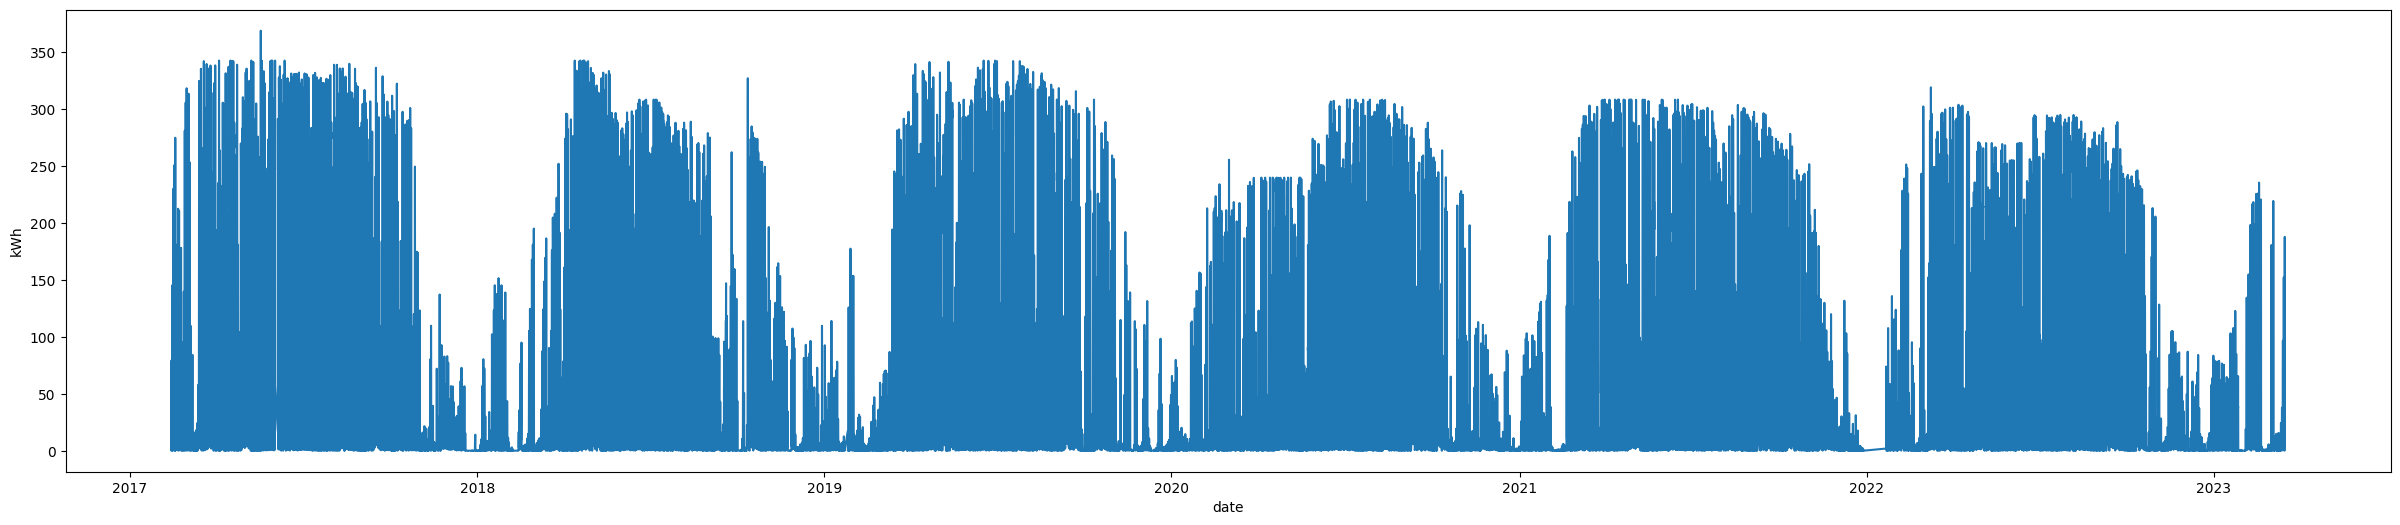

In [ ]:
plt.figure(figsize=(30, 6))
sns.lineplot(df[df.name == target_building], x="date", y="kWh")
plt.show()

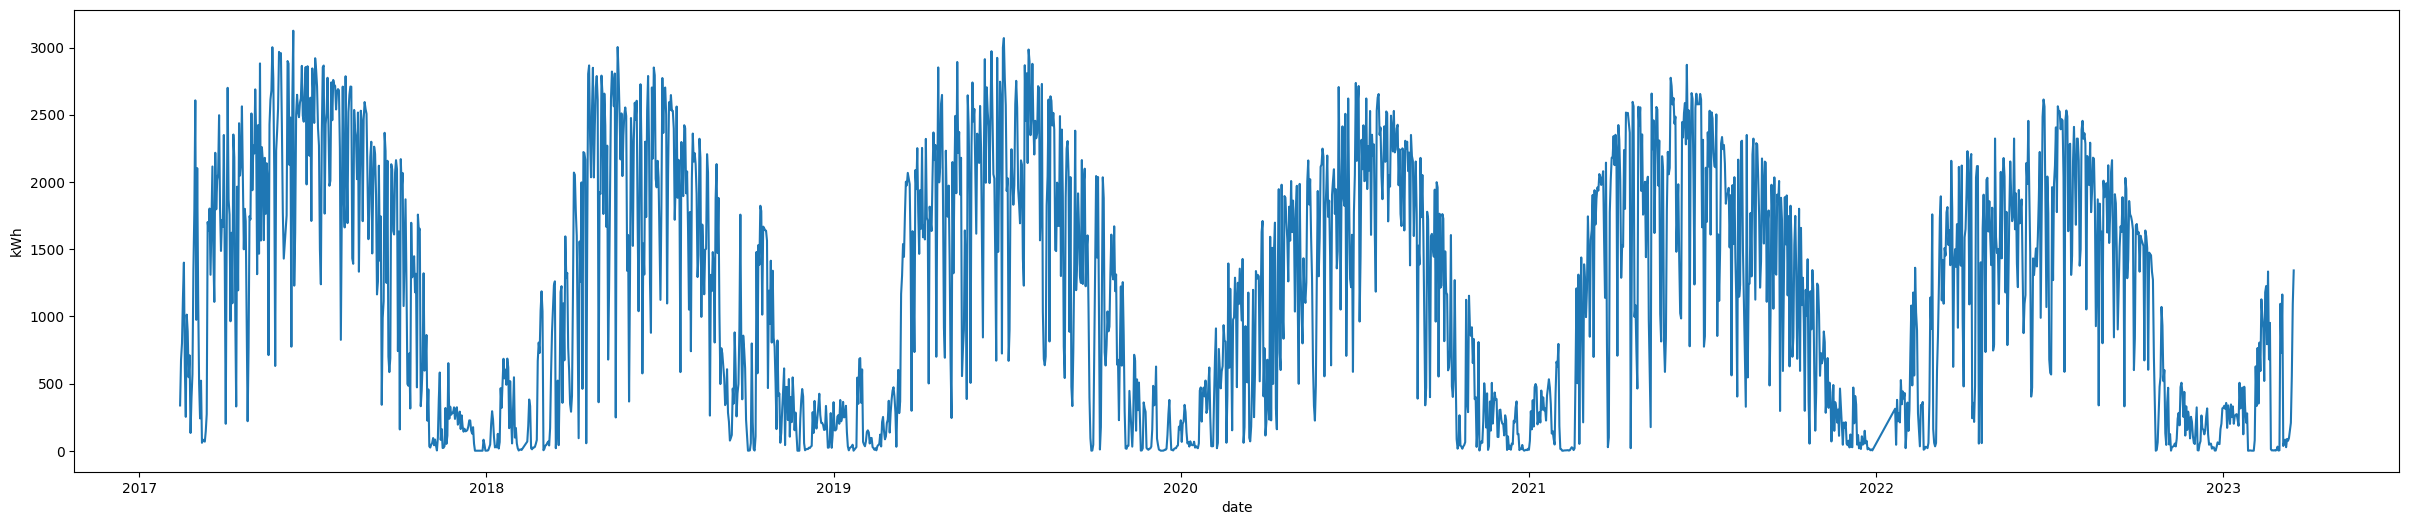

In [ ]:
df_by_day = df.groupby(["name", pd.Grouper(freq="D")]).agg(
    {
        'kWh': 'sum',
        'month': 'first'
    }
)

target = df_by_day.xs(target_building, level='name')

plt.figure(figsize=(30, 6))
sns.lineplot(data = target, x = target.index, y="kWh")
plt.show()

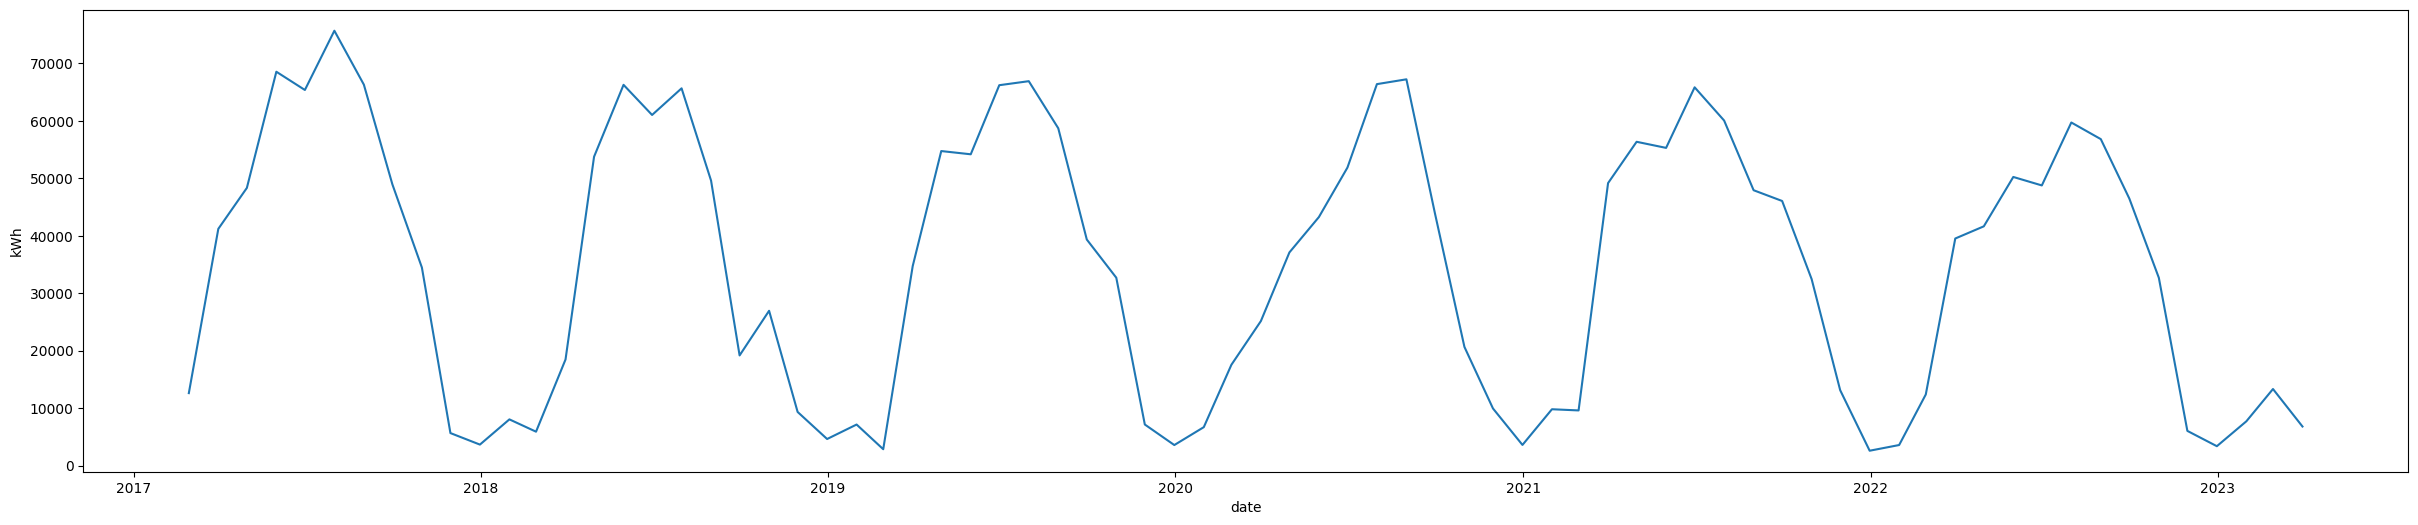

In [ ]:
df_by_month = df.groupby(["name", pd.Grouper(freq="ME")]).agg(
    {
        'kWh': 'sum',
        'month': 'first'
    }
)
target = df_by_month.xs(target_building, level='name')
plt.figure(figsize=(30, 6))
sns.lineplot(data = target, x = target.index, y="kWh")
plt.show()

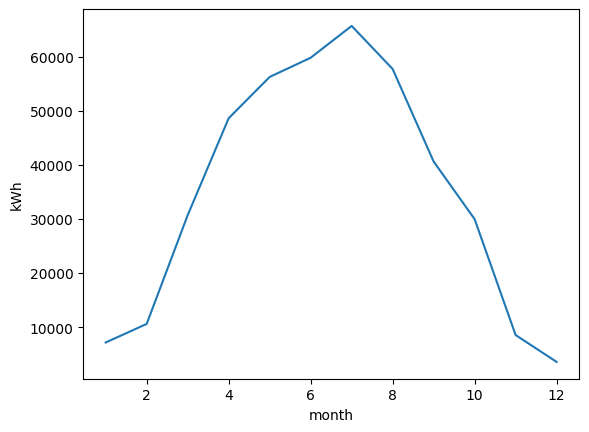

In [ ]:

target = df_by_month.xs(target_building, level = 'name')

target = target.groupby("month").mean()
sns.lineplot(data = target, x = 'month', y = 'kWh')
plt.show()

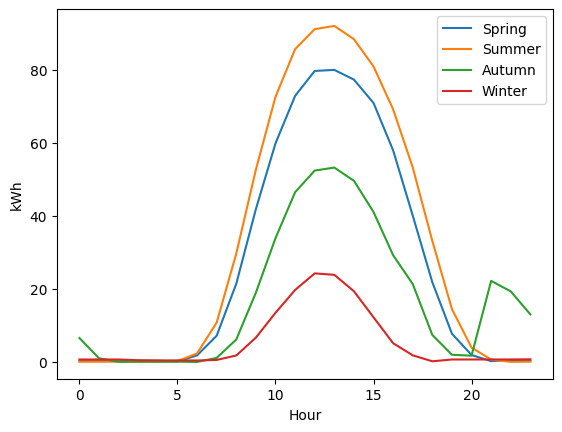

In [ ]:
df_spring = df[(df.month == 3) | (df.month == 4) | (df.month == 5)]
df_summer = df[(df.month == 6) | (df.month == 7) | (df.month == 8)]
df_autumn = df[(df.month == 9) | (df.month == 10) | (df.month == 11)]
df_winter = df[(df.month == 12) | (df.month == 1) | (df.month == 2)]

dfs = [df_spring, df_summer, df_autumn, df_winter]

target_spring = df_spring.groupby(df_spring.index.hour).agg(
    {'kWh': 'mean'}
)
target_summer = df_summer.groupby(df_summer.index.hour).agg(
    {'kWh': 'mean'}
)
target_autumn = df_autumn.groupby(df_autumn.index.hour).agg(
    {'kWh': 'mean'}
)
target_winter = df_winter.groupby(df_winter.index.hour).agg(
    {'kWh': 'mean'}
)

targets = [target_spring, target_summer, target_autumn, target_winter]

for index, season in enumerate(targets):
    sns.lineplot(data=season, x=season.index, y='kWh', label=['Spring', 'Summer', 'Autumn', 'Winter'][index])

plt.xlabel("Hour")

plt.legend()
plt.show()

In [ ]:
# Find out about the wierd spike in late hours for autumn.
target = df_autumn[(df_autumn.index.hour > 20) & (df_autumn.kWh > 1)]
display(target) # Looks like southland is consistently wierd numbers at midnight

,name,id,address,date,kWh,public_url,installationDate,uid,month,hour,day
date,,,,,,,,,,,
2015-09-01 21:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-01 21:30:00,57.844,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-01 21:30:00,9,21,1
2015-09-01 22:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-01 22:30:00,48.606,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-01 22:30:00,9,22,1
2015-09-01 23:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-01 23:30:00,31.482,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-01 23:30:00,9,23,1
2015-09-02 21:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-02 21:30:00,35.959,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-02 21:30:00,9,21,2
2015-09-02 22:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-02 22:30:00,57.311,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-02 22:30:00,9,22,2
2015-09-02 23:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-02 23:30:00,13.246,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-02 23:30:00,9,23,2
2015-09-03 21:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-03 21:30:00,53.896,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-03 21:30:00,9,21,3
2015-09-03 22:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-03 22:30:00,47.704,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-03 22:30:00,9,22,3
2015-09-03 23:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-03 23:30:00,41.221,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-03 23:30:00,9,23,3


Good candidates:
Whitehorn,
Manchester (clean time range),
Richmond



In [ ]:
data = df[(df.name == "Whitehorn Multi-Service Centre") & (df.date > pd.to_datetime("2020", format="%Y"))].copy()



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from numpy import sin, cos, pi, ptp

#data['hour_sin'] = sin(2 * pi * data['hour'] / 24.0)
#data['hour_cos'] = cos(2 * pi * data['hour'] / 24.0)

#data['month_sin'] = sin(2 * pi * data['hour'] / 12.0)
#data['month_cos'] = cos(2 * pi * data['hour'] / 12.0)

#data['kWh_lag1'] = data['kWh'].shift(1)
#data['kWh_lag2'] = data['kWh'].shift(2)

#data['kWh_lag24'] = data['kWh'].shift(24)

data['DOY'] = data.date.dt.dayofyear - 1
data = data.copy()

#data['DOY_sin'] = sin(2 * pi * data['hour'] / 365.0)
#data['DOY_cos'] = cos(2 * pi * data['hour'] / 365.0)

def add_lag_features(df, target_col, lags):
    """Generates lag features for a given target column and list of lag intervals."""
    df = df.copy()
    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)
    return df

lag_steps = [1, 2, 3, 6, 12, 24, 48, 168]

data = add_lag_features(data, target_col="kWh", lags=lag_steps)
data = data.iloc[168:]


32.559729624551196 0.8607327664670426 19.927547489997895 24.650682458043462
Index(['name', 'id', 'address', 'date', 'kWh', 'public_url',
       'installationDate', 'uid', 'month', 'hour', 'day', 'DOY', 'kWh_lag_1',
       'kWh_lag_2', 'kWh_lag_3', 'kWh_lag_6', 'kWh_lag_12', 'kWh_lag_24',
       'kWh_lag_48', 'kWh_lag_168'],
      dtype='object')


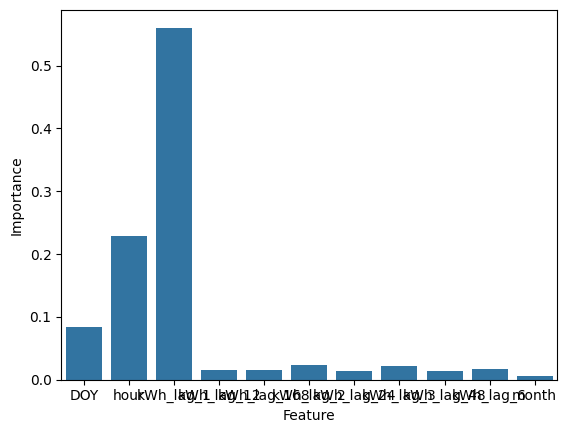

In [ ]:
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from numpy import sum, abs
#x = data[['month_sin', 'month_cos', 'DOY_sin', 'DOY_cos', 'hour_sin', 'hour_cos', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 36.254364760678094 0.8248486389497924 23.46417641279728
#x = data[['month', 'DOY', 'hour', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 31.12005383704525 0.8705738726313695 18.335540267154105
#x = data[['month', 'DOY', 'hour']] # 60.92139135385213 0.504242367929508 38.9335652916937
#x = data[['month', 'hour', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24', 'date']] # 31.564038317246762 0.8667215192040549 18.660708832684822
features = data.columns.difference(['kWh', 'date', 'name', 'id', 'address', 'installationDate', 'public_url', 'uid', 'day'])
x = data[features]
y = data['kWh']

split_idx = int(len(data) * (2 / 3))

train_x = x[:split_idx]
test_x = x[split_idx:]
train_y = y[:split_idx]
test_y = y[split_idx:]

model = RandomForestRegressor(n_estimators=100, random_state=69420)

model.fit(train_x, train_y)

predictions = model.predict(test_x)

rmse = root_mean_squared_error(test_y, predictions)
r2 = r2_score(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)
wape = (sum(abs(test_y - predictions)) / sum(test_y)) * 100
print(rmse, r2, mae, wape)
print(data.columns)
ax = sns.barplot(x=test_x.columns, y = model.feature_importances_)
ax.set(xlabel = "Feature", ylabel = "Importance")
plt.show()

In [ ]:
%%script true
test_data = pd.DataFrame()
test_data['date'] = test_x['date']
test_data['pred'] = predictions
test_data['real'] = test_y
test_data = test_data[(test_data['date'] > pd.to_datetime('3/2/2023', format="%m/%d/%Y")) & (test_data['date'] < pd.to_datetime('3/3/2023', format="%m/%d/%Y"))]
ax = sns.lineplot(x=test_data['date'], y = test_data['pred'])
ax2 = ax.twinx()
sns.lineplot(x=test_data['date'], y = test_data['real'], color='orange')

In [ ]:
from xgboost import XGBRegressor
#x = data[['month_sin', 'month_cos', 'DOY_sin', 'DOY_cos', 'hour_sin', 'hour_cos', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 36.254364760678094 0.8248486389497924 23.46417641279728
#x = data[['month', 'DOY', 'hour', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 31.12005383704525 0.8705738726313695 18.335540267154105
#x = data[['month', 'DOY', 'hour']] # 60.92139135385213 0.504242367929508 38.9335652916937
x = data[features] # 31.564038317246762 0.8667215192040549 18.660708832684822
y = data['kWh']

split_idx = int(len(data) * (2 / 3))

train_x = x[:split_idx]
test_x = x[split_idx:]
train_y = y[:split_idx]
test_y = y[split_idx:]

model = XGBRegressor(n_estimators=274, random_state=69420, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511)

model.fit(train_x, train_y)

predictions = model.predict(test_x)

rmse = root_mean_squared_error(test_y, predictions)
r2 = r2_score(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)
wape = (sum(abs(test_y - predictions)) / sum(test_y)) * 100
print(rmse, r2, mae, wape)

importance = pd.Series(
    model.feature_importances_, index=train_x.columns
)
print("\nFeature Importances:\n", importance.sort_values(ascending=False))

31.547821200272953 0.8692546926059824 19.988706419003805 24.72633699301097

Feature Importances:
 kWh_lag_1      0.461335
hour           0.211584
month          0.086098
DOY            0.062315
kWh_lag_2      0.058704
kWh_lag_3      0.031446
kWh_lag_6      0.021090
kWh_lag_48     0.018056
kWh_lag_168    0.016837
kWh_lag_12     0.016747
kWh_lag_24     0.015787
dtype: float32


In [ ]:
%%script true
!pip install optuna
import optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 69420,
    }

    model = XGBRegressor(**params)
    model.fit(train_x, train_y)

    preds = model.predict(test_x)
    rmse = root_mean_squared_error(test_y, preds)
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)

In [ ]:
from lightgbm import LGBMRegressor
#x = data[['month_sin', 'month_cos', 'DOY_sin', 'DOY_cos', 'hour_sin', 'hour_cos', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 36.254364760678094 0.8248486389497924 23.46417641279728
#x = data[['month', 'DOY', 'hour', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 31.12005383704525 0.8705738726313695 18.335540267154105
#x = data[['month', 'DOY', 'hour']] # 60.92139135385213 0.504242367929508 38.9335652916937
x = data[features] # 31.564038317246762 0.8667215192040549 18.660708832684822
y = data['kWh']

split_idx = int(len(data) * (2 / 3))

train_x = x[:split_idx]
test_x = x[split_idx:]
train_y = y[:split_idx]
test_y = y[split_idx:]

model = XGBRegressor(n_estimators=274, random_state=69420, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511)


model.fit(train_x, train_y)

predictions = model.predict(test_x)

rmse = root_mean_squared_error(test_y, predictions)
r2 = r2_score(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)
wape = (sum(abs(test_y - predictions)) / sum(test_y)) * 100
print(rmse, r2, mae, wape)

31.547821200272953 0.8692546926059824 19.988706419003805 24.72633699301097


In [ ]:
%%script true
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 69420,
    }

    model = LightGBMRegressor(**params)
    model.fit(train_x, train_y)

    preds = model.predict(test_x)

    rmse = root_mean_squared_error(test_y, preds)
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

print("Best Parameters:", study.best_params)

In [ ]:
LATITUDE = 51.08570494734326
LONGITUDE = -113.98363752368412
START_DATE = "2020-01-01"
END_DATE = "2023-03-16"

In [ ]:
%%script true
import requests

url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={LATITUDE}&longitude={LONGITUDE}&"
    f"start_date={START_DATE}&end_date={END_DATE}&"
    f"hourly=temperature_2m,cloud_cover,direct_normal_irradiance,diffuse_radiation,relative_humidity_2m&"
    f"timezone=GMT"
)

response = requests.get(url).json()
weather_df = pd.DataFrame(response["hourly"])

weather_df["date"] = pd.to_datetime(weather_df["time"])
weather_df = weather_df.drop(columns=["time"])
weather_df['date'] = pd.to_datetime(weather_df['date']).dt.tz_localize('UTC')

print(weather_df.head())

weather_df.to_csv("Whitehorn_weather.csv", index=False)

In [ ]:
weather_df = pd.read_csv("Whitehorn_weather.csv")
weather_df['date'] = pd.to_datetime(weather_df['date'])

In [ ]:

!pip install pvlib
import pvlib
data = df[(df.name == "Whitehorn Multi-Service Centre") & (df.date > pd.to_datetime("2020", format="%Y"))].copy()
data = data[data.columns.difference(['name', 'id', 'address', 'installationDate', 'public_url', 'uid'])]

data['date'] = data['date'].dt.tz_localize('America/Edmonton').dt.tz_convert('UTC')

data = data.reset_index(drop=True)
weather_df = weather_df.reset_index(drop=True)

data = pd.merge(data, weather_df, on='date', how="inner", suffixes=("", "_weather"))

data.sort_values('date').reset_index(drop=True)
data.set_index('date', drop=False)

times = pd.date_range("2020-01-01 00:00", "2023-03-16 23:00", freq="h", tz="UTC")
solpos = pvlib.solarposition.get_solarposition(times, LATITUDE, LONGITUDE)
elevation_df = pd.DataFrame ({
    'date': times,
    'elevation': solpos.elevation
})

data = pd.merge(data, elevation_df, on='date', how='inner', suffixes=('', '_elevation'))

data.sort_values('date').reset_index(drop=True)
data.set_index('date', drop=False)

lag_steps = [1, 2, 3, 6, 12, 24, 48, 168]

data = add_lag_features(data, target_col="kWh", lags=lag_steps)
data = data.iloc[168:]


In [ ]:
data['DOY'] = data.date.dt.dayofyear - 1
data = data.copy()

data.set_index('date', drop=False, inplace=True)
data.sort_index(inplace=True)

In [ ]:
from xgboost import XGBRegressor
#x = data[['month_sin', 'month_cos', 'DOY_sin', 'DOY_cos', 'hour_sin', 'hour_cos', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 36.254364760678094 0.8248486389497924 23.46417641279728
#x = data[['month', 'DOY', 'hour', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 31.12005383704525 0.8705738726313695 18.335540267154105
#x = data[['month', 'DOY', 'hour']] # 60.92139135385213 0.504242367929508 38.9335652916937
x = data[data.columns.difference(['kWh', 'day'])] # 31.564038317246762 0.8667215192040549 18.660708832684822
y = data['kWh']


split_idx = int(len(data) * (2 / 3))

train_x = x[:split_idx]
display(train_x.columns)
train_x = train_x[train_x.columns.difference(['date'])]

test_x = x[split_idx:]
test_x_no_date = test_x[test_x.columns.difference(['date'])]
train_y = y[:split_idx]
test_y = y[split_idx:]

model = XGBRegressor(n_estimators=274, random_state=69420, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511)


model.fit(train_x, train_y)

predictions = model.predict(test_x_no_date)

rmse = root_mean_squared_error(test_y, predictions)
r2 = r2_score(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)
wape = (sum(abs(test_y - predictions)) / sum(test_y)) * 100
print(rmse, r2, mae, wape)

importance = pd.Series(
    model.feature_importances_, index=train_x.columns
)
print("\nFeature Importances:\n", importance.sort_values(ascending=False))

Index(['DOY', 'cloud_cover', 'date', 'diffuse_radiation',
       'direct_normal_irradiance', 'elevation', 'hour', 'kWh_lag_1',
       'kWh_lag_12', 'kWh_lag_168', 'kWh_lag_2', 'kWh_lag_24', 'kWh_lag_3',
       'kWh_lag_48', 'kWh_lag_6', 'month', 'relative_humidity_2m',
       'temperature_2m'],
      dtype='object')

29.082529221979087 0.8934628671804246 17.52347214727272 20.236654650757956

Feature Importances:
 elevation                   0.492204
kWh_lag_1                   0.158023
hour                        0.083190
direct_normal_irradiance    0.052128
temperature_2m              0.035399
cloud_cover                 0.035214
diffuse_radiation           0.019284
relative_humidity_2m        0.016678
kWh_lag_2                   0.016340
month                       0.014743
kWh_lag_3                   0.013776
kWh_lag_6                   0.011648
kWh_lag_48                  0.010982
kWh_lag_168                 0.010981
kWh_lag_24                  0.010314
kWh_lag_12                  0.010034
DOY                         0.009062
dtype: float32


In [ ]:
%%script true
!pip install optuna
import optuna
def objective(trial):
    # Define hyperparameter ranges to sample
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 69420,
    }

    model = XGBRegressor(**params)
    model.fit(train_x, train_y)

    preds = model.predict(test_x)
    # Objective is to minimize RMSE on test/validation set
    rmse = root_mean_squared_error(test_y, preds)
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)

<Axes: xlabel='date', ylabel='real'>

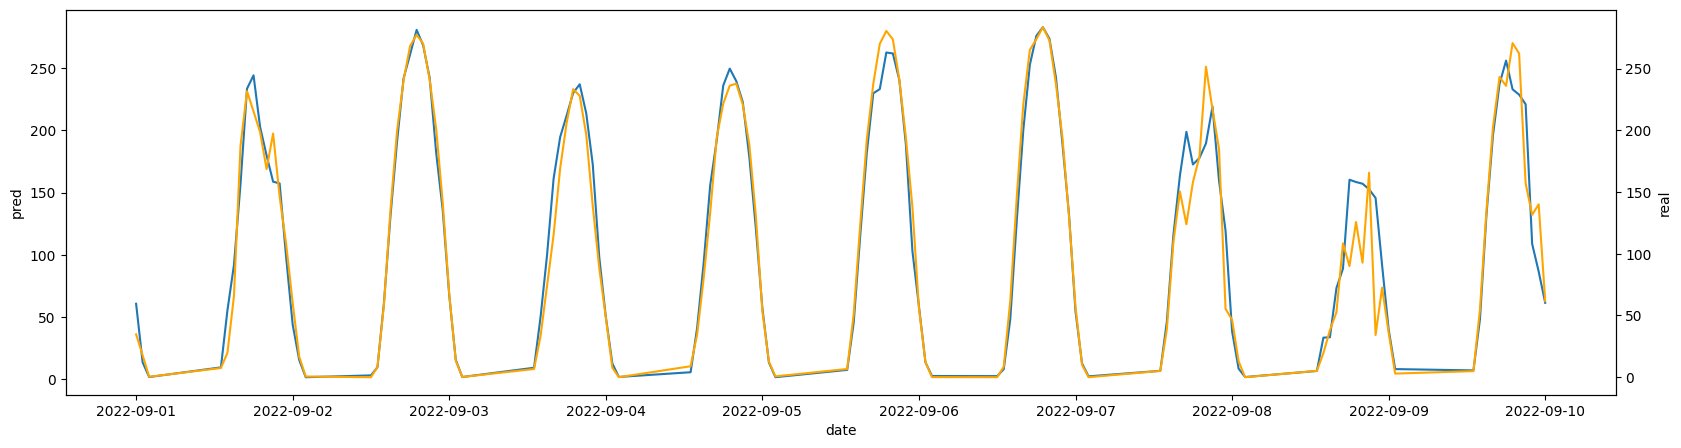

In [ ]:
res_df = pd.DataFrame({
    'date': test_x.date,
    'pred': predictions,
    'real': test_y
})

mask = (res_df['date'] >= '2022-09-01') & (res_df['date'] <= '2022-09-10')

res_df = res_df[mask]

plt.figure(figsize=(20, 5))
ax = sns.lineplot(x=res_df['date'], y = res_df['pred'])
ax2 = ax.twinx()
sns.lineplot(x=res_df['date'], y = res_df['real'], color='orange')

In [ ]:
weather_df.set_index('date', inplace=True, drop=False)
elevation_df.set_index('date', inplace=True, drop=False)

data = weather_df.merge(
    data,
    left_index=True,
    right_index=True,
    how="left",
    suffixes=("", "_orig")
)

data = data.drop(columns=data.filter(like="_orig").columns)

data = elevation_df.merge(
    data,
    left_index=True,
    right_index=True,
    how="left",
    suffixes=("", "_orig")
)

data = data.drop(columns=data.filter(like="_orig").columns)
data = data.drop(columns = ['month', 'hour', 'day', 'DOY'])

local_index = data.index.tz_convert('America/Edmonton')
data['month'] = local_index.month
data['hour'] = local_index.hour
data['day'] = local_index.day
data['DOY'] = local_index.dayofyear - 1
data.fillna({'kWh': 0}, inplace=True)

In [ ]:
import numpy as np
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

def recursive_forecast(model, df_full, start_datetime, num_steps, base_feature_columns, lag_steps, train_feature_columns):
    max_lag = max(lag_steps)

    start_idx_loc = df_full.index.get_loc(start_datetime)

    initial_kwh_history = df_full.iloc[start_idx_loc - max_lag : start_idx_loc]['kWh'].tolist()

    forecasted_kwh = []
    forecasted_dates = []

    current_kwh_history = list(initial_kwh_history)

    for i in range(num_steps):
        current_forecast_datetime = df_full.index[start_idx_loc + i]
        forecasted_dates.append(current_forecast_datetime)

        current_features_series = df_full.loc[current_forecast_datetime, base_feature_columns].copy()

        for lag in lag_steps:

            if len(current_kwh_history) >= lag:
                current_features_series[f'kWh_lag_{lag}'] = current_kwh_history[-lag]
            else:
                current_features_series[f'kWh_lag_{lag}'] = np.nan


        model_input = pd.DataFrame([current_features_series.values], columns=current_features_series.index)
        model_input = model_input[train_feature_columns]

        prediction = model.predict(model_input)[0]
        forecasted_kwh.append(prediction)

        current_kwh_history.append(prediction)
        current_kwh_history.pop(0)

    return pd.Series(forecasted_kwh, index=forecasted_dates, name='predicted_kWh_recursive')


--- 48-Hour Recursive Forecast ---
2022-09-01 00:00:00+00:00     60.063488
2022-09-01 01:00:00+00:00     14.506217
2022-09-01 02:00:00+00:00      2.377002
2022-09-01 03:00:00+00:00      4.796772
2022-09-01 04:00:00+00:00      4.067085
                                ...    
2022-09-10 19:00:00+00:00    276.379211
2022-09-10 20:00:00+00:00    262.220276
2022-09-10 21:00:00+00:00    232.723145
2022-09-10 22:00:00+00:00    181.360764
2022-09-10 23:00:00+00:00    122.756004
Name: predicted_kWh_recursive, Length: 240, dtype: float32

--- Actual kWh for Forecast Period ---
2022-09-01 00:00:00+00:00     34.727
2022-09-01 01:00:00+00:00     17.823
2022-09-01 02:00:00+00:00      0.358
2022-09-01 03:00:00+00:00      0.000
2022-09-01 04:00:00+00:00      0.000
                              ...   
2022-09-10 19:00:00+00:00    230.752
2022-09-10 20:00:00+00:00    240.591
2022-09-10 21:00:00+00:00    215.215
2022-09-10 22:00:00+00:00    183.423
2022-09-10 23:00:00+00:00    123.359
Name: kWh, Length:

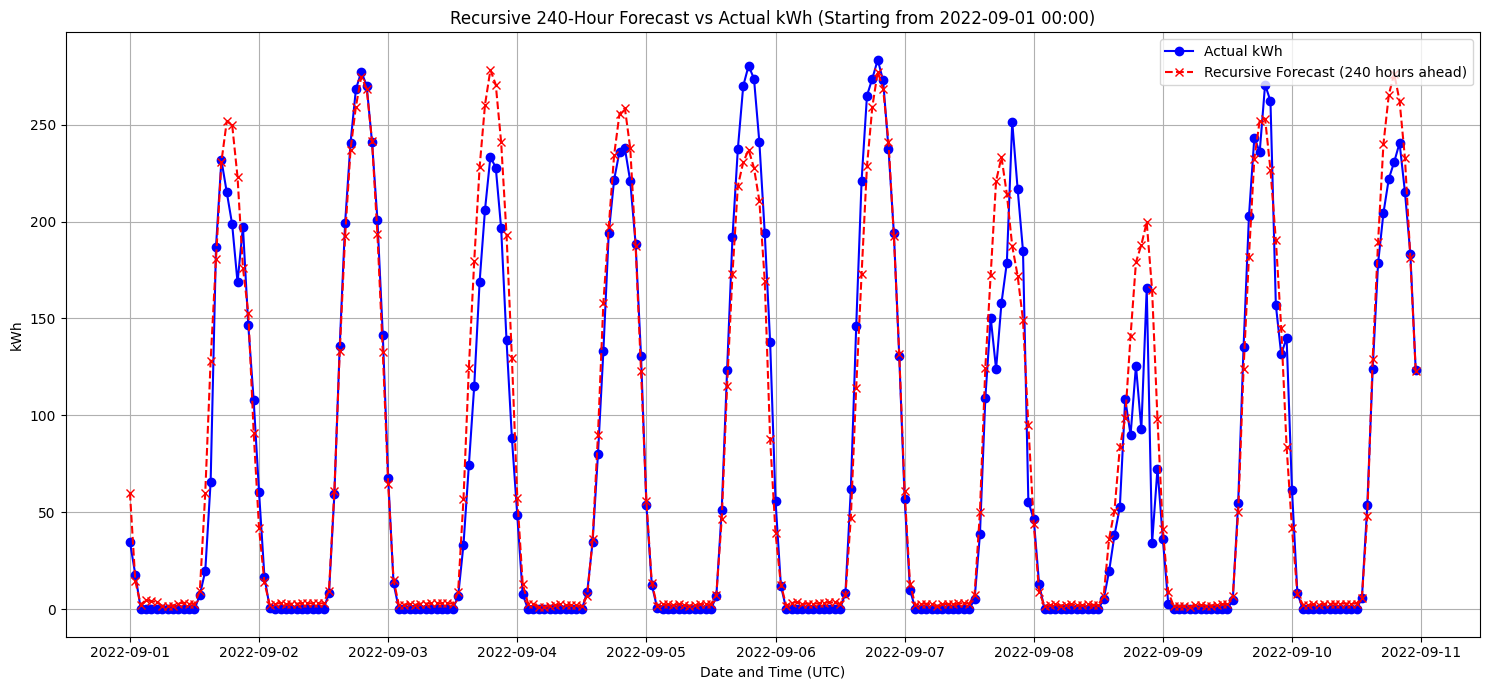

RMSE for 240-hour recursive forecast: 23.469919202381895
R2 Score for 240-hour recursive forecast: 0.9370673926845432
MAE for 240-hour recursive forecast: 13.014672007719676
WAPE for 240-hour recursive forecast: 17.949202418690824


In [ ]:
base_feature_columns = [col for col in train_x.columns if not col.startswith('kWh_lag_')]


train_feature_columns = train_x.columns.tolist()

start_forecast_date = pd.to_datetime('2022-09-01 00:00:00+00:00')

num_forecast_steps = 240

recursive_predictions = recursive_forecast(model, data, start_forecast_date, num_forecast_steps, base_feature_columns, lag_steps, train_feature_columns)

print("\n--- 48-Hour Recursive Forecast ---")
print(recursive_predictions)

actual_kwh_for_forecast_period = data.loc[recursive_predictions.index, 'kWh']
print("\n--- Actual kWh for Forecast Period ---")
print(actual_kwh_for_forecast_period)

plt.figure(figsize=(15, 7))
plt.plot(actual_kwh_for_forecast_period.index, actual_kwh_for_forecast_period.values, label='Actual kWh', marker='o', linestyle='-', color='blue')
plt.plot(recursive_predictions.index, recursive_predictions.values, label=f'Recursive Forecast ({num_forecast_steps} hours ahead)', marker='x', linestyle='--', color='red')

plt.title(f'Recursive {num_forecast_steps}-Hour Forecast vs Actual kWh (Starting from {start_forecast_date.strftime("%Y-%m-%d %H:%M")})')
plt.xlabel('Date and Time (UTC)')
plt.ylabel('kWh')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

res_df = pd.DataFrame({
    'pred': recursive_predictions,
    'real': actual_kwh_for_forecast_period
})

res_df.dropna(inplace=True)

rmse_rec = root_mean_squared_error(res_df['real'], res_df['pred'])
r2_rec = r2_score(res_df['real'], res_df['pred'])
mae_rec = mean_absolute_error(res_df['real'], res_df['pred'])
wape_rec = (np.sum(np.abs(res_df['real'] - res_df['pred'])) / np.sum(res_df['real'])) * 100

print(f"RMSE for {num_forecast_steps}-hour recursive forecast: {rmse_rec}")
print(f"R2 Score for {num_forecast_steps}-hour recursive forecast: {r2_rec}")
print(f"MAE for {num_forecast_steps}-hour recursive forecast: {mae_rec}")
print(f"WAPE for {num_forecast_steps}-hour recursive forecast: {wape_rec}")

In [ ]:
def create_windowed_dataframe(
    df: pd.DataFrame,
    input_cols: list[str],
    output_cols: list[str],
    lookback: int,
    horizon: int
) -> tuple[pd.DataFrame, pd.DataFrame, list[str], list[str]]:
    input_dict = {}
    output_dict = {}

    for col in input_cols:
        for i in range(lookback):
            input_dict[f"{col}_lag_t-{i}"] = df[col].shift(i)

        for j in range(1, horizon + 1):
            input_dict[f"{col}_future_t+{j}"] = df[col].shift(-j)

    for col in output_cols:
        for j in range(1, horizon + 1):
            output_dict[f"{col}_target_t+{j}"] = df[col].shift(-j)

    # Construct individual DataFrames
    df_x = pd.DataFrame(input_dict, index=df.index)
    df_y = pd.DataFrame(output_dict, index=df.index)

    # Combine and drop NaNs together to maintain aligned indices
    df_combined = pd.concat([df_x, df_y], axis=1).dropna()

    x_cols = list(input_dict.keys())
    y_cols = list(output_dict.keys())

    X = df_combined[x_cols]
    Y = df_combined[y_cols]

    return X, Y

In [ ]:
import cudf

data_extended = data.copy()

prefix = "kWh_lag"

# Keep only columns that do NOT start with the prefix
data_extended = data_extended[data_extended.columns.difference(data_extended.filter(regex=f"^{prefix}").columns)]

input_features = ['DOY', 'diffuse_radiation', 'direct_normal_irradiance', 'elevation', 'hour', 'month', 'relative_humidity_2m', 'temperature_2m']
output_features = ['kWh']

data_extended.fillna({'kWh': 0}, inplace=True)

x, y = create_windowed_dataframe(data_extended, input_features, output_features, 24, 24)

split_idx = int(len(data) * (2 / 3))

train_x = x[:split_idx]
test_x = x[split_idx:]
train_y = y[:split_idx]
test_y = y[split_idx:]

train_x_gpu = cudf.DataFrame(train_x)
train_y_gpu = cudf.DataFrame(train_y)

test_x_gpu = cudf.DataFrame(test_x)
test_y_gpu = cudf.DataFrame(test_y)



In [ ]:
# CURRENT 24 HOUR MODEL

model_24xgb = XGBRegressor(n_estimators=274, random_state=69420, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511, tree_method='hist', device='cuda')

model_24xgb.fit(train_x_gpu, train_y_gpu)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.921776337426511, device='cuda',
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.016402891919412303,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=274, n_jobs=None,
             num_parallel_tree=None, ...)

In [ ]:
predictions = model_24xgb.predict(test_x_gpu)

In [ ]:
test_y_np = test_y.to_numpy()

#daylight_mask = test_y_np > 0.1
#predictions_daylight = predictions[daylight_mask]
#test_y_np = test_y_np[daylight_mask]

mae = mean_absolute_error(test_y_np, predictions)
r2 = r2_score(test_y_np, predictions)
rmse = root_mean_squared_error(test_y_np, predictions)

print(rmse, r2, mae)

26.428774754238674 0.8826253670132505 12.133558665362857


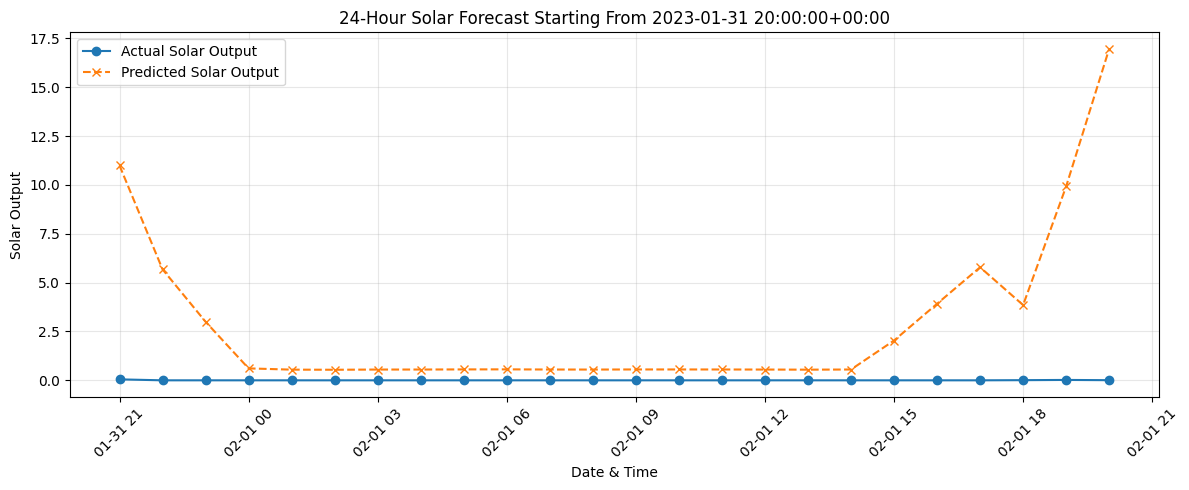

In [ ]:
sample_idx = 8285
'''
interesting idx:
8265: no data
4625: 2022-09-01
200: bad data?

Early months are bad:
Coincidentally: Calgary recieves the most snowfall in early spring with march and april getting the most snow
Snow covering panels could definitely affect power produced add snowfall to weather data?

'''

start_time = test_x.index[sample_idx]

forecast_dates = pd.date_range(start=start_time + pd.Timedelta(hours=1), periods=24, freq='h')

y_pred_series = pd.Series(predictions[sample_idx], index=forecast_dates)
y_true_series = pd.Series(test_y.to_numpy()[sample_idx], index=forecast_dates)

plt.figure(figsize=(12, 5))
plt.plot(y_true_series.index, y_true_series, label='Actual Solar Output', marker='o')
plt.plot(y_pred_series.index, y_pred_series, label='Predicted Solar Output', linestyle='--', marker='x')

plt.title(f'24-Hour Solar Forecast Starting From {start_time}')
plt.xlabel('Date & Time')
plt.ylabel('Solar Output')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
!pip install "darts[torch]"

from darts import TimeSeries
from darts.models import TiDEModel
from darts.dataprocessing.transformers import Scaler

data_tcn = data.copy()

prefix = "kWh_lag"

# Keep only columns that do NOT start with the prefix
data_extended = data_extended[data_extended.columns.difference(data_extended.filter(regex=f"^{prefix}").columns)]

data_tcn["hour_sin"] = np.sin(2 * np.pi * data_tcn["hour"] / 24.0)
data_tcn["hour_cos"] = np.cos(2 * np.pi * data_tcn["hour"] / 24.0)

# 2. Month (Period = 12, shifting by -1 if 1-indexed from 1 to 12)
data_tcn["month_sin"] = np.sin(2 * np.pi * (data_tcn["month"] - 1) / 12.0)
data_tcn["month_cos"] = np.cos(2 * np.pi * (data_tcn["month"] - 1) / 12.0)

# 3. Day of Year / DOY (Period = 365, shifting by -1 if 1-indexed from 1 to 365)
data_tcn["DOY_sin"] = np.sin(2 * np.pi * (data_tcn["DOY"]) / 365.0)
data_tcn["DOY_cos"] = np.cos(2 * np.pi * (data_tcn["DOY"]) / 365.0)

#stats before sin/cos transform 51.2813795859614 38.50579885824457 0.7525277213505558
#stats after: 48.55543960054029 0.778137992868655 35.490059156640754


target_series = TimeSeries.from_dataframe(
    data_tcn, value_cols=["kWh"], fill_missing_dates=True, freq="1h"
)

covariates_series = TimeSeries.from_dataframe(
    data_tcn, value_cols = [
        'elevation', 'temperature_2m', 'cloud_cover', 'direct_normal_irradiance',
        'diffuse_radiation', 'relative_humidity_2m','hour_sin', 'hour_cos',
        'month_sin', 'month_cos', 'DOY_sin', 'DOY_cos'],
    fill_missing_dates=True, freq="1h"
)

target_train, target_val = target_series.split_after(0.66)

target_scaler = Scaler()
covariates_scaler = Scaler()

target_train = target_scaler.fit_transform(target_train)
target_val = target_scaler.transform(target_val)

covariates = covariates_scaler.fit_transform(covariates_series)


In [ ]:
import torch
from pytorch_lightning.callbacks import EarlyStopping

torch.set_float32_matmul_precision("medium")

early_stopper = EarlyStopping(
    monitor="val_loss", patience=7, min_delta=1e-4, mode="min"
)

model = TiDEModel(
    input_chunk_length=24,
    output_chunk_length=24,
    num_encoder_layers=2,  # Default is 1
    num_decoder_layers=2,  # Default is 1
    hidden_size=128,  # Default is 128
    decoder_output_dim=32,  # Default is 16
    #temporal_decoder_hidden_size=64,  # Default is 32
    dropout=0.3,  # Increase slightly to prevent overfitting with larger capacity
    n_epochs=64,
    batch_size=64,
    random_state=42,
    force_reset=True,
    pl_trainer_kwargs={
        "accelerator": "gpu",
        "devices": 1,
        "callbacks": [early_stopper],
    },
    optimizer_kwargs={
        "lr": 3e-4,  # Lower learning rate (default is 1e-3)
        "weight_decay": 1e-4,  # L2 regularization
    },
)

model.fit(
    series=target_train,
    future_covariates=covariates,
    val_series=target_val,
    val_future_covariates=covariates,
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion             │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion       │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion         │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 5 │ future_cov_projection │ _ResidualBlock   │  2.2 K │ train │     0 │
│ 6 │ encoders              │ Sequential       │  121 K │ train │     0 │
│ 7 │ decoders              │ Sequential       │  264 K │ train │     0 │
│ 8 │ temporal_decoder      │ _ResidualBlock   │  1.3 K │ train │     0 │
│ 9 │ lookback_skip         │ Linear           │    600 │ train │     0 │
└───┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 389 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 389 K                                                                                                
Total estimated model params size (MB): 3.119                                                                      
Modules in train mode: 50                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

TiDEModel(output_chunk_shift=0, num_encoder_layers=2, num_decoder_layers=2, decoder_output_dim=32, hidden_size=128, temporal_width_past=4, temporal_width_future=4, temporal_hidden_size_past=None, temporal_hidden_size_future=None, temporal_decoder_hidden=32, use_layer_norm=False, dropout=0.3, use_static_covariates=True, input_chunk_length=24, output_chunk_length=24, n_epochs=64, batch_size=64, random_state=42, force_reset=True, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': 1, 'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x7f0cb3fe2390>]}, optimizer_kwargs={'lr': 0.0003, 'weight_decay': 0.0001})

In [ ]:
from darts import metrics

full_target = target_train.concatenate(target_val)

historical_forecasts = model.historical_forecasts(
    series=full_target,
    future_covariates=covariates,
    start=target_val.start_time(),
    forecast_horizon=24,
    stride=1,
    retrain=False,
    verbose=True,
)

historical_forecasts = target_scaler.inverse_transform(historical_forecasts)

actual_val = target_val[historical_forecasts.start_time() : historical_forecasts.end_time()]

actual_val = target_scaler.inverse_transform(actual_val)

historical_forecasts = historical_forecasts.map(lambda x: np.maximum(0, x))

rmse = metrics.rmse(actual_val, historical_forecasts)
mae = metrics.mae(actual_val, historical_forecasts)
r2 = metrics.r2_score(actual_val, historical_forecasts)
#mape = metrics.smape(actual_val, historical_forecasts)

print(rmse,r2,mae)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

29.356546688966265 0.8534411017689224 14.538117796072909


In [ ]:
actual_vals = actual_val.values().flatten()
forecast_vals = historical_forecasts.values().flatten()

# 2. Create a boolean mask for daylight hours (where actual > 0.1)
daylight_mask = actual_vals > 0.1

# 3. Filter arrays using the mask
actual_daylight = actual_vals[daylight_mask]
forecast_daylight = forecast_vals[daylight_mask]

# 4. Calculate SMAPE manually on daylight hours
daylight_smape = (
    np.mean(
        2
        * np.abs(forecast_daylight - actual_daylight)
        / (np.abs(actual_daylight) + np.abs(forecast_daylight))
    )
    * 100
)

print(f"Daylight SMAPE: {daylight_smape:.2f}%")

Daylight SMAPE: 60.14%


In [ ]:
start_time = pd.Timestamp("2022-09-01 08:00:00")
end_time = pd.Timestamp("2022-09-02 09:00:00")

full_series = target_train.concatenate(target_val)

historical_context = full_series[:start_time]

# 6. Predict
forecast_scaled = model.predict(
    n=24,
    series=historical_context,
    future_covariates=covariates,
)

forecast = target_scaler.inverse_transform(forecast_scaled)

forecast = forecast.map(lambda x: np.maximum(0, x))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


<Figure size 1200x600 with 0 Axes>

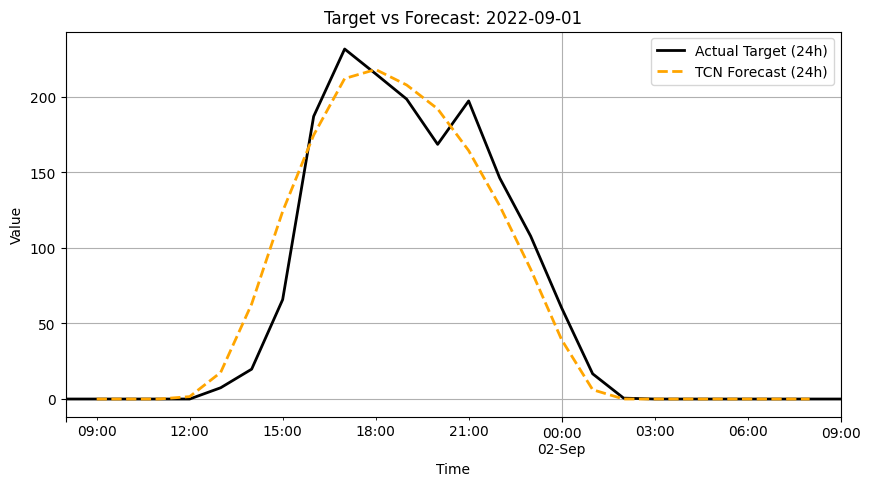

In [ ]:
# Set figure size
plt.figure(figsize=(12, 6))

actual_24h = target_series.slice(start_time, end_time)
forecast_24h = forecast.slice(start_time, end_time)

plt.figure(figsize=(10, 5))
actual_24h.plot(label="Actual Target (24h)", color="black", linewidth=2)
forecast_24h.plot(
    label="TCN Forecast (24h)", color="orange", linestyle="--", linewidth=2
)

plt.title(f"Target vs Forecast: {start_time.date()}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()